# RMA Benchmark Analysis
## Lock/Unlock vs Fence vs PSCW vs SendRecv Performance Comparison
### Including Put and Get Operations

In [13]:
import re
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

In [14]:
def parse_benchmark_file(filename):
    results = []
    
    ansi_escape = re.compile(r'\x1B(?:[@-Z\\-_]|\[[0-?]*[ -/]*[@-~])')
    
    with open(filename, 'r') as f:
        for line in f:
            clean_line = ansi_escape.sub('', line)
            
            if 'raw_benchmark' in clean_line:
                continue
            match = re.search(
                r'benchmark_(\w+)/(\d+)/manual_time\s+([\d.]+)\s+us.*bytes_per_second=([\d.]+)(Ki|Mi|Gi)/s',
                clean_line
            )
            
            if match:
                operation_raw = match.group(1)

                operation = operation_raw.replace('lock_unlock_put', 'LockUnlockPut') \
                                        .replace('lock_unlock_get', 'LockUnlockGet') \
                                        .replace('lock_unlock_accumulate', 'LockUnlockAccumulate') \
                                        .replace('fence_put', 'FencePut') \
                                        .replace('fence_get', 'FenceGet') \
                                        .replace('fence_accumulate', 'FenceAccumulate') \
                                        .replace('pscw_put', 'PSCWPut') \
                                        .replace('pscw_get', 'PSCWGet') \
                                        .replace('pscw_accumulate', 'PSCWAccumulate') \
                                        .replace('sendrecv_comparison', 'SendRecv')
                
                msg_size = int(match.group(2))
                time_us = float(match.group(3))
                throughput = float(match.group(4))
                unit = match.group(5)
                
                # Convert to Gi/s
                if unit == 'Ki':
                    throughput_gis = throughput / (1024.0 * 1024.0)
                elif unit == 'Mi':
                    throughput_gis = throughput / 1024.0
                else:
                    throughput_gis = throughput
                
                results.append({
                    'Operation': operation,
                    'MessageSize': msg_size,
                    'Time_us': time_us,
                    'Throughput_Gis': throughput_gis
                })
    
    return pd.DataFrame(results)

df = parse_benchmark_file('results.txt')

print(f"Loaded {len(df)} benchmarks")

Loaded 70 benchmarks


In [15]:
df

,Operation,MessageSize,Time_us,Throughput_Gis
0,LockUnlockPut,1,4.530,0.001646
1,LockUnlockPut,8,4.810,0.012398
2,LockUnlockPut,64,5.180,0.092072
3,LockUnlockPut,512,6.010,0.634358
4,LockUnlockPut,4096,7.320,4.168690
...,...,...,...,...
65,SendRecv,64,0.255,3.733870
66,SendRecv,512,0.359,21.223600
67,SendRecv,4096,1.620,37.788100
68,SendRecv,32768,13.000,37.564200


['LockUnlockPut' 'LockUnlockGet' 'LockUnlockAccumulate' 'FencePut'
 'FenceGet' 'FenceAccumulate' 'PSCWPut' 'PSCWGet' 'PSCWAccumulate'
 'SendRecv']


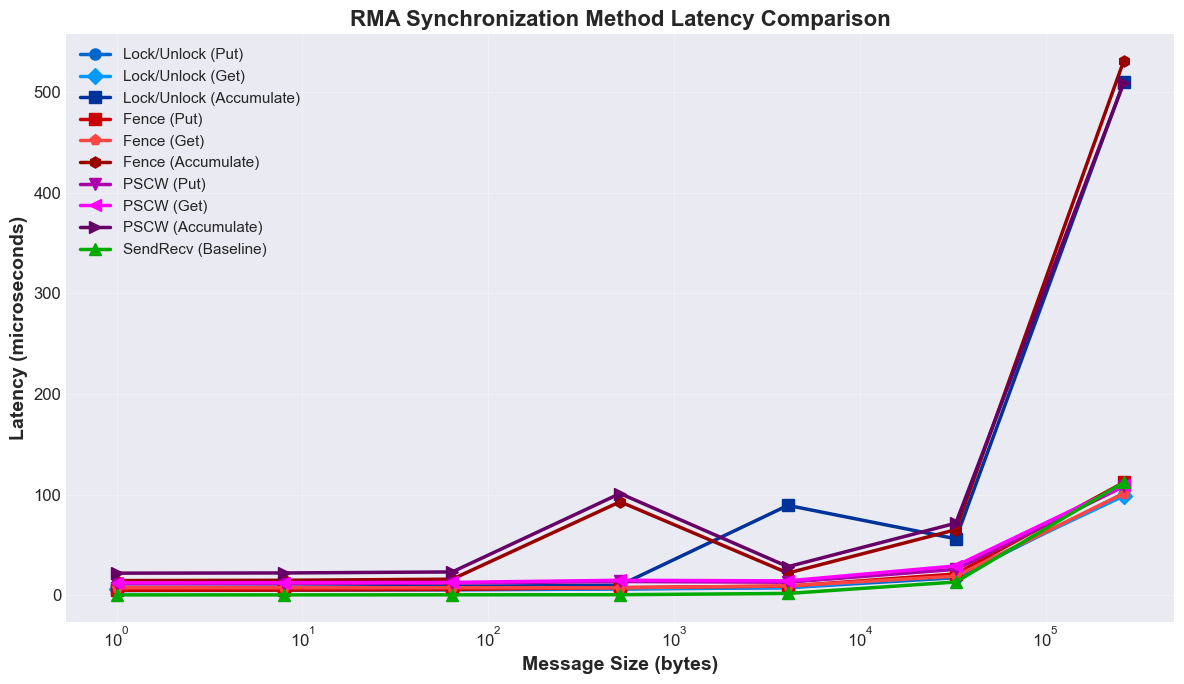

Graph saved as: latency_comparison.png


In [16]:
fig, ax = plt.subplots(figsize=(12, 7))

operations = df['Operation'].unique()
print(operations)

colors = {
    'LockUnlockPut':        '#0066CC',
    'LockUnlockGet':        '#0099FF',
    'LockUnlockAccumulate': '#003399',
    'FencePut':             '#CC0000',
    'FenceGet':             '#FF4444',
    'FenceAccumulate':      '#990000',
    'PSCWPut':              '#AA00AA',
    'PSCWGet':              '#FF00FF',
    'PSCWAccumulate':       '#660066',
    'SendRecv':             '#00AA00',
}

markers = {
    'LockUnlockPut':        'o',
    'LockUnlockGet':        'D',
    'LockUnlockAccumulate': 's',
    'FencePut':             's',
    'FenceGet':             'p',
    'FenceAccumulate':      'h',
    'PSCWPut':              'v',
    'PSCWGet':              '<',
    'PSCWAccumulate':       '>',
    'SendRecv':             '^',
}

label_map = {
    'LockUnlockPut':        'Lock/Unlock (Put)',
    'LockUnlockGet':        'Lock/Unlock (Get)',
    'LockUnlockAccumulate': 'Lock/Unlock (Accumulate)',
    'FencePut':             'Fence (Put)',
    'FenceGet':             'Fence (Get)',
    'FenceAccumulate':      'Fence (Accumulate)',
    'PSCWPut':              'PSCW (Put)',
    'PSCWGet':              'PSCW (Get)',
    'PSCWAccumulate':       'PSCW (Accumulate)',
    'SendRecv':             'SendRecv (Baseline)',
}

for op in operations:
    data_subset = df[df['Operation'] == op]
    ax.plot(data_subset['MessageSize'], data_subset['Time_us'], 
            marker=markers.get(op, 'o'), linewidth=2.5, markersize=8,
            label=label_map.get(op, op),
            color=colors.get(op, '#000000'))

ax.set_xscale('log')
ax.set_xlabel('Message Size (bytes)', fontsize=14, fontweight='bold')
ax.set_ylabel('Latency (microseconds)', fontsize=14, fontweight='bold')
ax.set_title('RMA Synchronization Method Latency Comparison', fontsize=16, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('latency_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Graph saved as: latency_comparison.png")

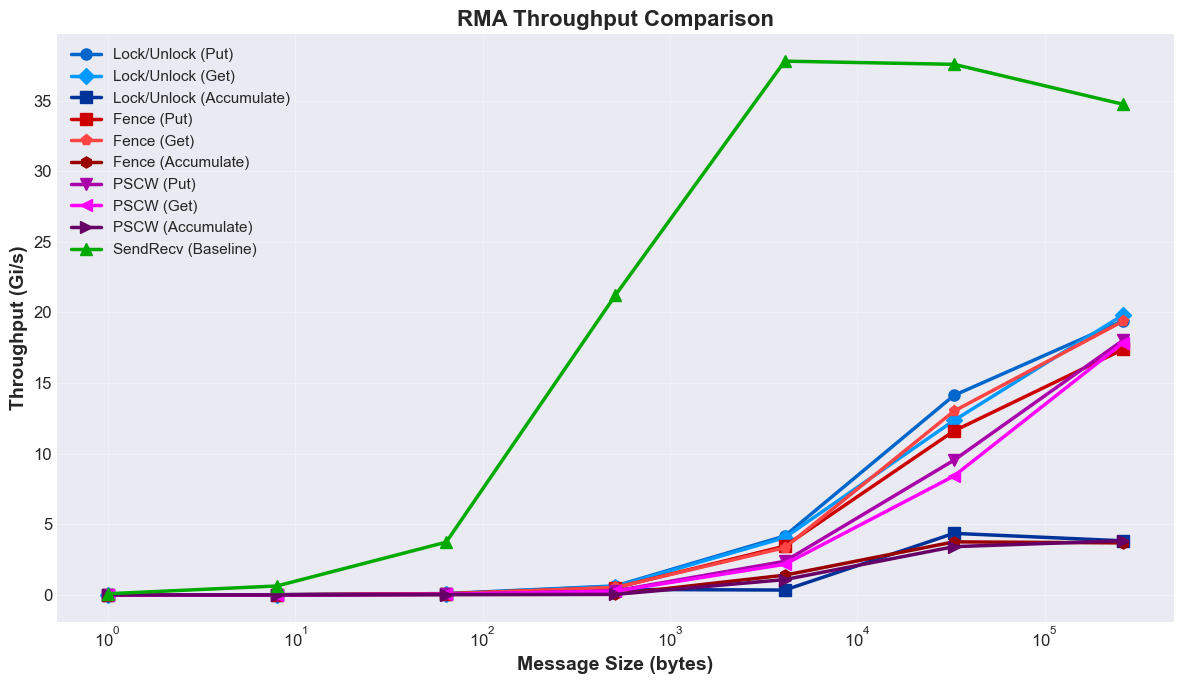

Graph saved as: throughput_comparison.png


In [17]:
fig, ax = plt.subplots(figsize=(12, 7))

for op in operations:
    data_subset = df[df['Operation'] == op]
    ax.plot(data_subset['MessageSize'], data_subset['Throughput_Gis'], 
            marker=markers.get(op, 'o'), linewidth=2.5, markersize=8,
            label=label_map.get(op, op),
            color=colors.get(op, '#000000'))

ax.set_xscale('log')
ax.set_xlabel('Message Size (bytes)', fontsize=14, fontweight='bold')
ax.set_ylabel('Throughput (Gi/s)', fontsize=14, fontweight='bold')
ax.set_title('RMA Throughput Comparison', fontsize=16, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('throughput_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Graph saved as: throughput_comparison.png")

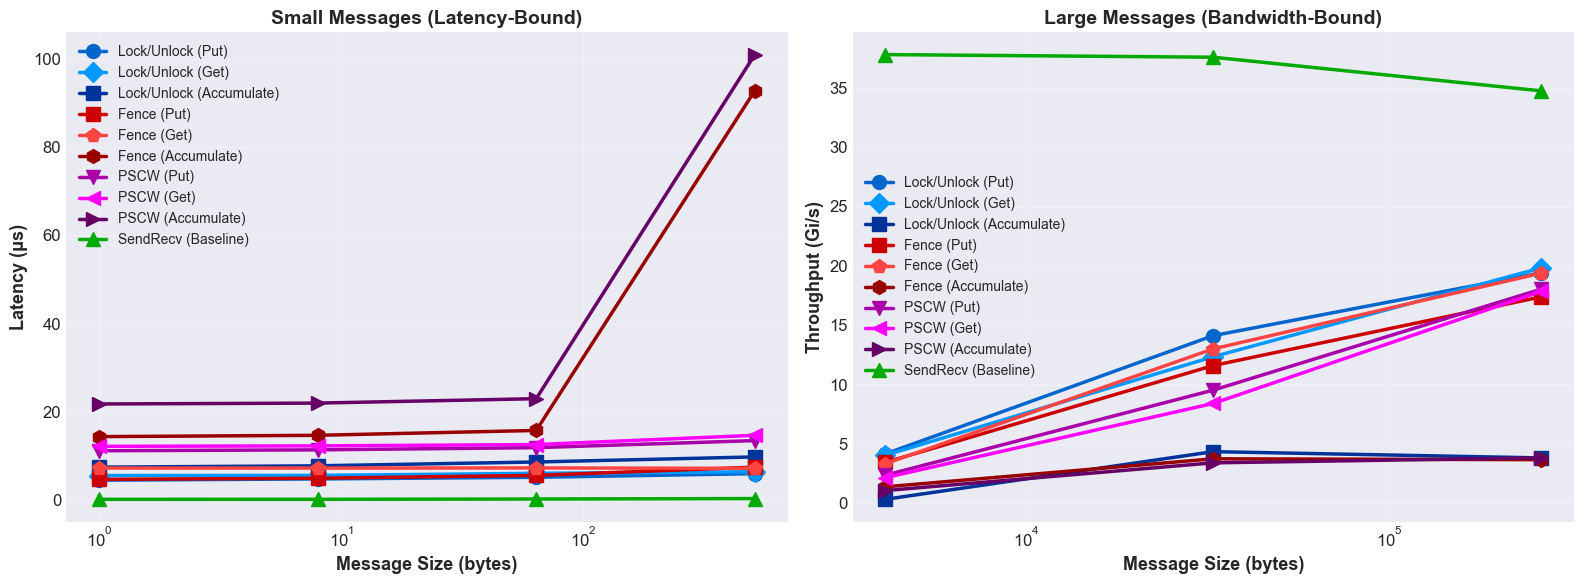

Graph saved as: small_vs_large_comparison.png


In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

small_sizes = [1, 8, 64, 512]
for op in operations:
    if op in df['Operation'].values:
        data_subset = df[(df['Operation'] == op) & (df['MessageSize'].isin(small_sizes))]
        ax1.plot(data_subset['MessageSize'], data_subset['Time_us'], 
                marker=markers.get(op, 'o'), linewidth=2.5, markersize=10,
                label=label_map.get(op, op),
                color=colors.get(op, '#000000'))

ax1.set_xscale('log')
ax1.set_xlabel('Message Size (bytes)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Latency (μs)', fontsize=13, fontweight='bold')
ax1.set_title('Small Messages (Latency-Bound)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

large_sizes = [4096, 32768, 262144]
for op in operations:
    if op in df['Operation'].values:
        data_subset = df[(df['Operation'] == op) & (df['MessageSize'].isin(large_sizes))]
        ax2.plot(data_subset['MessageSize'], data_subset['Throughput_Gis'], 
                marker=markers.get(op, 'o'), linewidth=2.5, markersize=10,
                label=label_map.get(op, op),
                color=colors.get(op, '#000000'))

ax2.set_xscale('log')
ax2.set_xlabel('Message Size (bytes)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Throughput (Gi/s)', fontsize=13, fontweight='bold')
ax2.set_title('Large Messages (Bandwidth-Bound)', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('small_vs_large_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Graph saved as: small_vs_large_comparison.png")

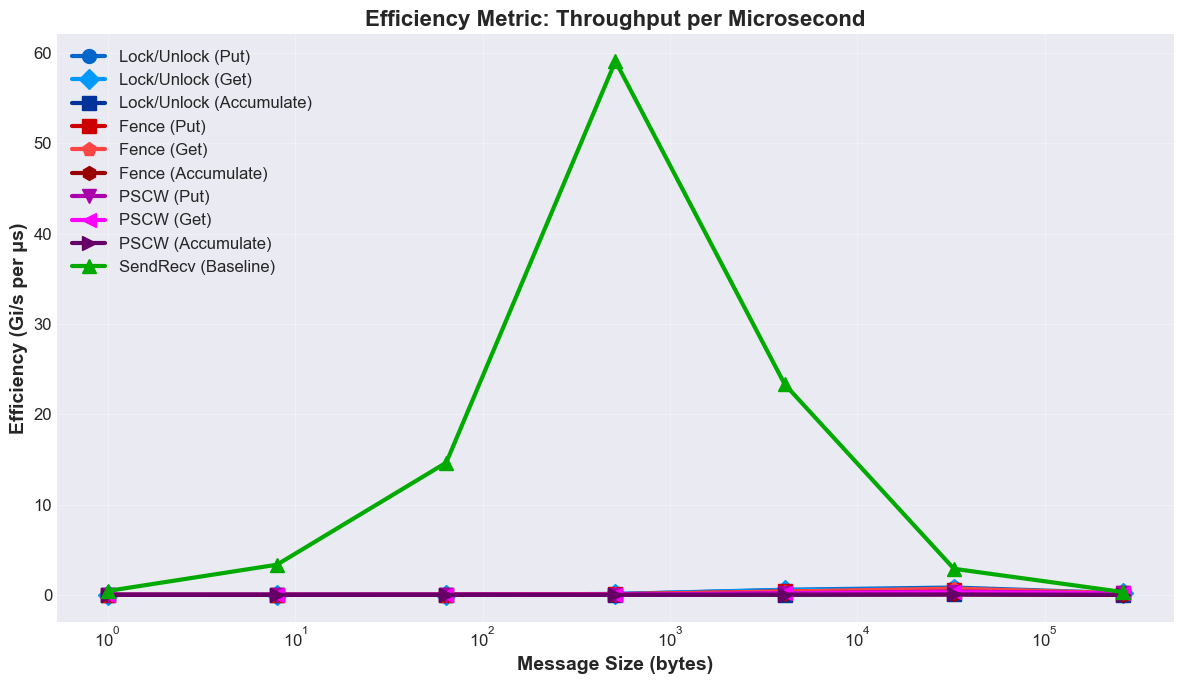

Graph saved as: efficiency_metric.png


In [19]:
fig, ax = plt.subplots(figsize=(12, 7))

for op in operations:
    if op in df['Operation'].values:
        data_subset = df[df['Operation'] == op].copy()
        data_subset['Efficiency'] = data_subset['Throughput_Gis'] / data_subset['Time_us']

        ax.plot(data_subset['MessageSize'], data_subset['Efficiency'],
                marker=markers.get(op, 'o'), linewidth=3, markersize=10,
                label=label_map.get(op, op),
                color=colors.get(op, '#000000'))

ax.set_xscale('log')
ax.set_xlabel('Message Size (bytes)', fontsize=14, fontweight='bold')
ax.set_ylabel('Efficiency (Gi/s per μs)', fontsize=14, fontweight='bold')
ax.set_title('Efficiency Metric: Throughput per Microsecond', fontsize=16, fontweight='bold')
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('efficiency_metric.png', dpi=300, bbox_inches='tight')
plt.show()

print("Graph saved as: efficiency_metric.png")

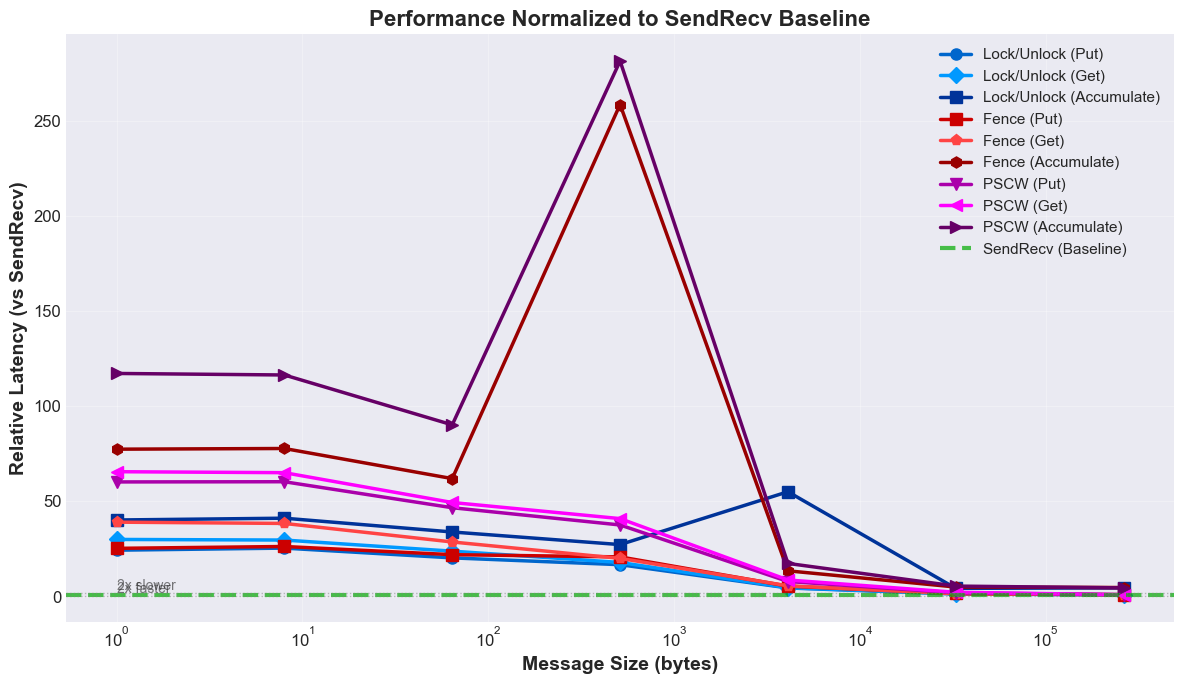

Graph saved as: normalized_performance.png


In [20]:
sendrecv_data = df[df['Operation'] == 'SendRecv'][['MessageSize', 'Time_us']].rename(columns={'Time_us': 'SendRecv_Time'})
normalized_df = df.merge(sendrecv_data, on='MessageSize')
normalized_df['Relative_Latency'] = normalized_df['Time_us'] / normalized_df['SendRecv_Time']

fig, ax = plt.subplots(figsize=(12, 7))

for op in operations:
    if op != 'SendRecv':
        data_subset = normalized_df[normalized_df['Operation'] == op]
        ax.plot(data_subset['MessageSize'], data_subset['Relative_Latency'], 
                marker=markers.get(op, 'o'), linewidth=2.5, markersize=8,
                label=label_map.get(op, op),
                color=colors.get(op, '#000000'))

ax.axhline(y=1.0, color='#00AA00', linestyle='--', linewidth=3, label='SendRecv (Baseline)', alpha=0.7)
ax.set_xscale('log')
ax.set_xlabel('Message Size (bytes)', fontsize=14, fontweight='bold')
ax.set_ylabel('Relative Latency (vs SendRecv)', fontsize=14, fontweight='bold')
ax.set_title('Performance Normalized to SendRecv Baseline', fontsize=16, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)

ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax.axhline(y=2.0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax.text(1, 0.5, '2x faster', fontsize=10, alpha=0.6, va='bottom')
ax.text(1, 2.0, '2x slower', fontsize=10, alpha=0.6, va='bottom')

plt.tight_layout()
plt.savefig('normalized_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("Graph saved as: normalized_performance.png")

## KokkosComm vs Raw MPI — Per Synchronization Method

Solid lines = KokkosComm wrapper. Dashed lines = Raw MPI calls. Lines of the same color/marker are the same operation. Overlap confirms zero abstraction overhead.

In [21]:
# Extended parser — reads raw_benchmark_ entries alongside KokkosComm ones.
# Creates df_raw separately so df above is unaffected.
import re as _re

_rma_map = {
    "lock_unlock_put":        "LockUnlockPut",
    "lock_unlock_get":        "LockUnlockGet",
    "lock_unlock_accumulate": "LockUnlockAccumulate",
    "fence_put":              "FencePut",
    "fence_get":              "FenceGet",
    "fence_accumulate":       "FenceAccumulate",
    "pscw_put":               "PSCWPut",
    "pscw_get":               "PSCWGet",
    "pscw_accumulate":        "PSCWAccumulate",
    "sendrecv_comparison":    "SendRecv",
}
_ansi = _re.compile(r"\x1B(?:[@-Z\\-_]|\[[0-?]*[ -/]*[@-~])")
_rma_re = _re.compile(
    r"(?:raw_)?benchmark_(\w+)/(\d+)/manual_time\s+([\d.]+)\s+us.*bytes_per_second=([\d.]+)(Ki|Mi|Gi)/s"
)

_rows = []
with open("results.txt", "r") as _f:
    for _line in _f:
        _cl = _ansi.sub("", _line)
        _m = _rma_re.search(_cl)
        if _m:
            _op = _rma_map.get(_m.group(1))
            if _op is None:
                continue
            _is_raw = "raw_benchmark" in _cl
            _tput = float(_m.group(4))
            _tgi = _tput / 1024.0 if _m.group(5) == "Mi" else _tput
            _rows.append({
                "Operation":      ("Raw_" if _is_raw else "") + _op,
                "MessageSize":    int(_m.group(2)),
                "Time_us":        float(_m.group(3)),
                "Throughput_Gis": _tgi,
            })

import pandas as _pd
df_raw = _pd.DataFrame(_rows)
print(f"df_raw loaded: {len(df_raw)} rows")
print("Operations:", sorted(df_raw["Operation"].unique()))


df_raw loaded: 133 rows
Operations: ['FenceAccumulate', 'FenceGet', 'FencePut', 'LockUnlockAccumulate', 'LockUnlockGet', 'LockUnlockPut', 'PSCWAccumulate', 'PSCWGet', 'PSCWPut', 'Raw_FenceAccumulate', 'Raw_FenceGet', 'Raw_FencePut', 'Raw_LockUnlockAccumulate', 'Raw_LockUnlockGet', 'Raw_LockUnlockPut', 'Raw_PSCWAccumulate', 'Raw_PSCWGet', 'Raw_PSCWPut', 'SendRecv']


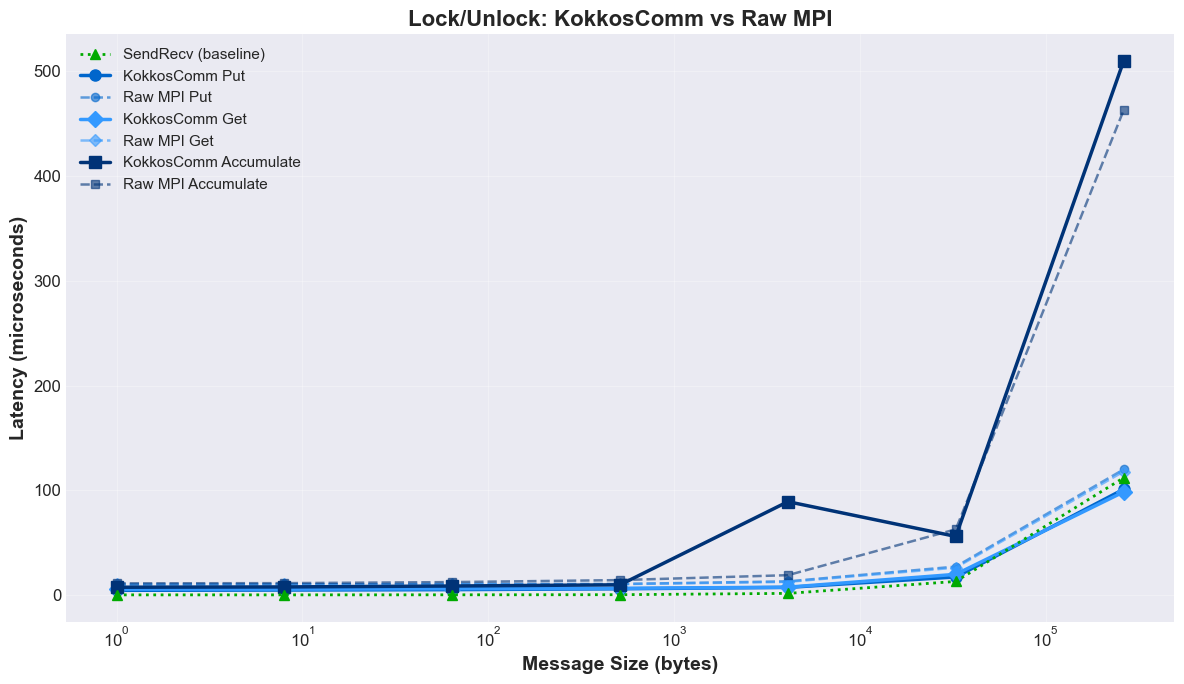

Graph saved as: lock_unlock_kokkos_vs_raw.png


In [22]:
# Lock/Unlock: KokkosComm vs Raw MPI
fig, ax = plt.subplots(figsize=(12, 7))

_sr = df_raw[df_raw["Operation"] == "SendRecv"]
if not _sr.empty:
    ax.plot(_sr["MessageSize"], _sr["Time_us"], marker="^", linewidth=2, markersize=7,
            color="#00AA00", linestyle=":", label="SendRecv (baseline)", zorder=5)

_pairs = [('LockUnlockPut', 'Raw_LockUnlockPut', '#0066CC', 'o', 'Put'), ('LockUnlockGet', 'Raw_LockUnlockGet', '#3399FF', 'D', 'Get'), ('LockUnlockAccumulate', 'Raw_LockUnlockAccumulate', '#003377', 's', 'Accumulate')]
for _kk_op, _raw_op, _color, _marker, _oplabel in _pairs:
    _kk  = df_raw[df_raw["Operation"] == _kk_op]
    _raw = df_raw[df_raw["Operation"] == _raw_op]
    if not _kk.empty:
        ax.plot(_kk["MessageSize"], _kk["Time_us"], marker=_marker, linewidth=2.5, markersize=8,
                color=_color, linestyle="-", label=f"KokkosComm {_oplabel}")
    if not _raw.empty:
        ax.plot(_raw["MessageSize"], _raw["Time_us"], marker=_marker, linewidth=1.8, markersize=6,
                color=_color, linestyle="--", label=f"Raw MPI {_oplabel}", alpha=0.6)

ax.set_xscale("log")
ax.set_xlabel("Message Size (bytes)", fontsize=14, fontweight="bold")
ax.set_ylabel("Latency (microseconds)", fontsize=14, fontweight="bold")
ax.set_title("Lock/Unlock: KokkosComm vs Raw MPI", fontsize=16, fontweight="bold")
ax.legend(fontsize=11, loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("lock_unlock_kokkos_vs_raw.png", dpi=300, bbox_inches="tight")
plt.show()
print("Graph saved as: lock_unlock_kokkos_vs_raw.png")


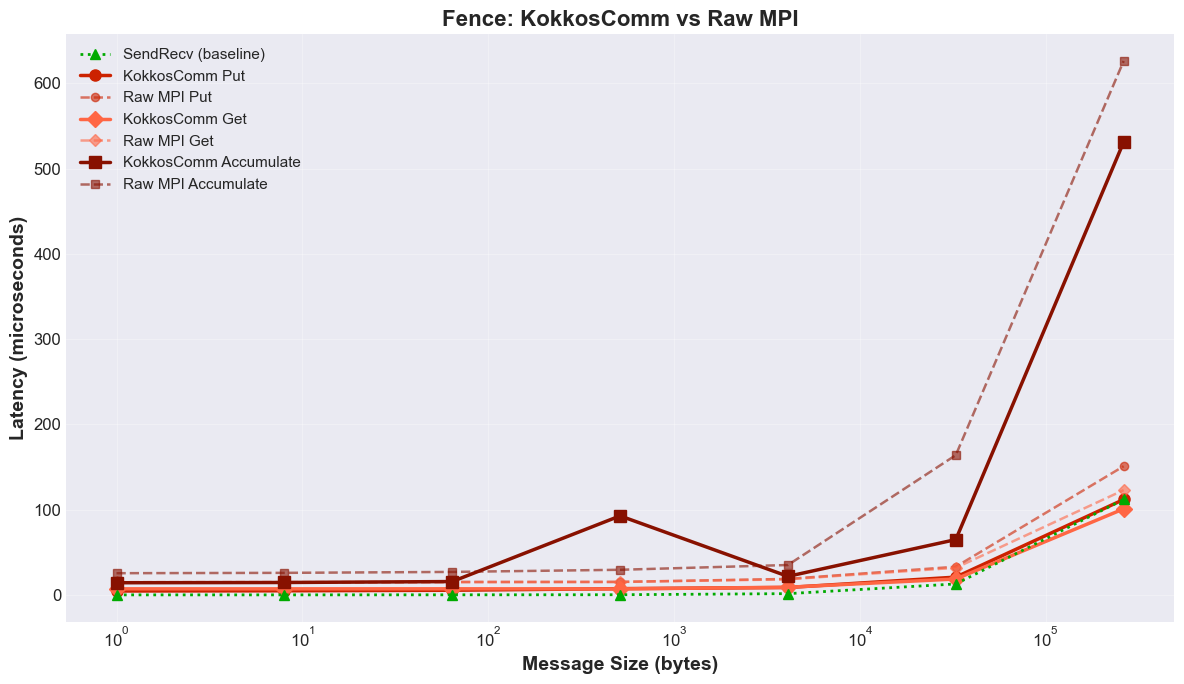

Graph saved as: fence_kokkos_vs_raw.png


In [23]:
# Fence: KokkosComm vs Raw MPI
fig, ax = plt.subplots(figsize=(12, 7))

_sr = df_raw[df_raw["Operation"] == "SendRecv"]
if not _sr.empty:
    ax.plot(_sr["MessageSize"], _sr["Time_us"], marker="^", linewidth=2, markersize=7,
            color="#00AA00", linestyle=":", label="SendRecv (baseline)", zorder=5)

_pairs = [('FencePut', 'Raw_FencePut', '#CC2200', 'o', 'Put'), ('FenceGet', 'Raw_FenceGet', '#FF6644', 'D', 'Get'), ('FenceAccumulate', 'Raw_FenceAccumulate', '#881100', 's', 'Accumulate')]
for _kk_op, _raw_op, _color, _marker, _oplabel in _pairs:
    _kk  = df_raw[df_raw["Operation"] == _kk_op]
    _raw = df_raw[df_raw["Operation"] == _raw_op]
    if not _kk.empty:
        ax.plot(_kk["MessageSize"], _kk["Time_us"], marker=_marker, linewidth=2.5, markersize=8,
                color=_color, linestyle="-", label=f"KokkosComm {_oplabel}")
    if not _raw.empty:
        ax.plot(_raw["MessageSize"], _raw["Time_us"], marker=_marker, linewidth=1.8, markersize=6,
                color=_color, linestyle="--", label=f"Raw MPI {_oplabel}", alpha=0.6)

ax.set_xscale("log")
ax.set_xlabel("Message Size (bytes)", fontsize=14, fontweight="bold")
ax.set_ylabel("Latency (microseconds)", fontsize=14, fontweight="bold")
ax.set_title("Fence: KokkosComm vs Raw MPI", fontsize=16, fontweight="bold")
ax.legend(fontsize=11, loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("fence_kokkos_vs_raw.png", dpi=300, bbox_inches="tight")
plt.show()
print("Graph saved as: fence_kokkos_vs_raw.png")


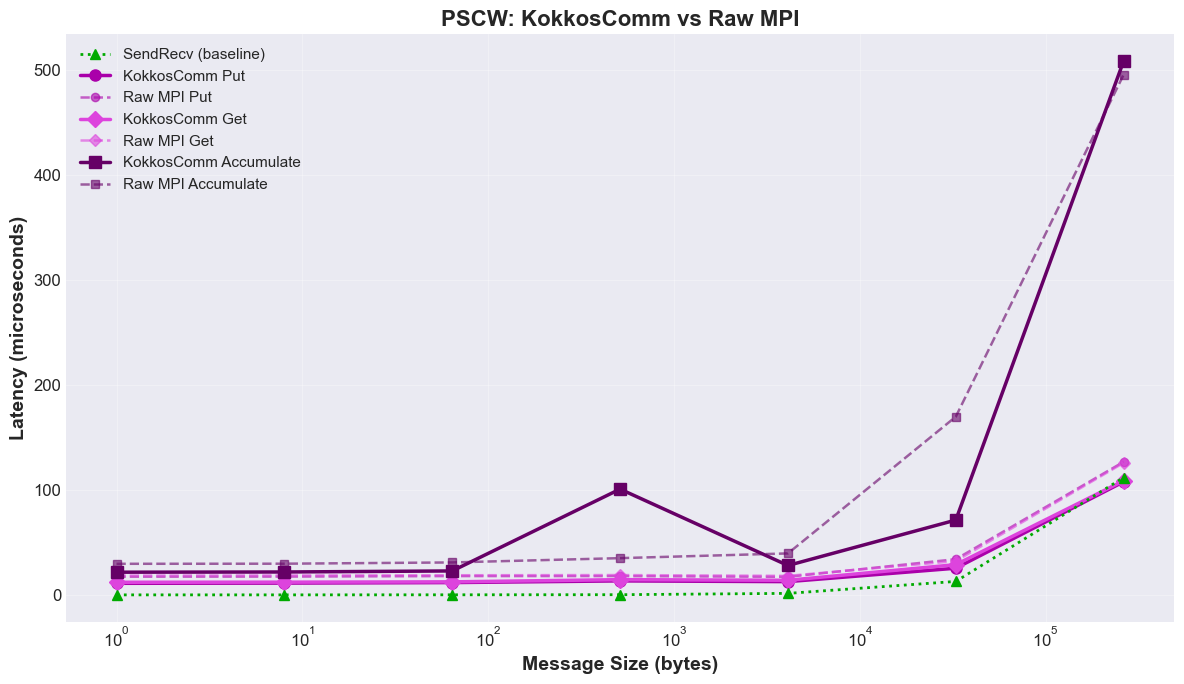

Graph saved as: pscw_kokkos_vs_raw.png


In [24]:
# PSCW: KokkosComm vs Raw MPI
fig, ax = plt.subplots(figsize=(12, 7))

_sr = df_raw[df_raw["Operation"] == "SendRecv"]
if not _sr.empty:
    ax.plot(_sr["MessageSize"], _sr["Time_us"], marker="^", linewidth=2, markersize=7,
            color="#00AA00", linestyle=":", label="SendRecv (baseline)", zorder=5)

_pairs = [('PSCWPut', 'Raw_PSCWPut', '#AA00AA', 'o', 'Put'), ('PSCWGet', 'Raw_PSCWGet', '#DD44DD', 'D', 'Get'), ('PSCWAccumulate', 'Raw_PSCWAccumulate', '#660066', 's', 'Accumulate')]
for _kk_op, _raw_op, _color, _marker, _oplabel in _pairs:
    _kk  = df_raw[df_raw["Operation"] == _kk_op]
    _raw = df_raw[df_raw["Operation"] == _raw_op]
    if not _kk.empty:
        ax.plot(_kk["MessageSize"], _kk["Time_us"], marker=_marker, linewidth=2.5, markersize=8,
                color=_color, linestyle="-", label=f"KokkosComm {_oplabel}")
    if not _raw.empty:
        ax.plot(_raw["MessageSize"], _raw["Time_us"], marker=_marker, linewidth=1.8, markersize=6,
                color=_color, linestyle="--", label=f"Raw MPI {_oplabel}", alpha=0.6)

ax.set_xscale("log")
ax.set_xlabel("Message Size (bytes)", fontsize=14, fontweight="bold")
ax.set_ylabel("Latency (microseconds)", fontsize=14, fontweight="bold")
ax.set_title("PSCW: KokkosComm vs Raw MPI", fontsize=16, fontweight="bold")
ax.legend(fontsize=11, loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("pscw_kokkos_vs_raw.png", dpi=300, bbox_inches="tight")
plt.show()
print("Graph saved as: pscw_kokkos_vs_raw.png")
